### Setting the right environment

In [2]:
import os

# Change to your project root
os.chdir(r'c:\Users\User\OneDrive\Documents\DTU\46770 - Integrated energy grids\DTU-Course---Integrated-Energy-Grids')

# Verify it worked
print(os.getcwd())

c:\Users\User\OneDrive\Documents\DTU\46770 - Integrated energy grids\DTU-Course---Integrated-Energy-Grids


### Loading time series data foronshore wind, offshore wind and solar PV capacity factors

In [5]:
import pandas as pd
import numpy as np

# Load the data
onshore_wind_df = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';', index_col=0, parse_dates=True)
pv_df = pd.read_csv('data/pv_optimal.csv', sep=';', index_col=0, parse_dates=True)
offshore_wind_df = pd.read_csv('data/offshore_wind_1979-2017.csv', sep=';', index_col=0, parse_dates=True)


# Quick check
print("Onshore wind data first 5 rows: ")
print(onshore_wind_df.head())
print("-------------------")
print("-------------------")
print("Offshore wind data first 5 rows: ")
print(offshore_wind_df.head())
print("-------------------")
print("-------------------")
print("Solar PV data first 5 rows: ")
print(pv_df.head())

Onshore wind data first 5 rows: 
                             AUT    BEL    BGR    CHE    CZE    DEU    DNK  \
utc_time                                                                     
1979-01-01 00:00:00+00:00  0.481  0.513  0.756  0.932  0.305  0.298  0.712   
1979-01-01 01:00:00+00:00  0.551  0.380  0.750  0.950  0.346  0.300  0.704   
1979-01-01 02:00:00+00:00  0.602  0.246  0.733  0.963  0.397  0.304  0.673   
1979-01-01 03:00:00+00:00  0.484  0.170  0.688  0.949  0.415  0.297  0.635   
1979-01-01 04:00:00+00:00  0.387  0.125  0.647  0.909  0.426  0.299  0.604   

                             ESP    EST    FIN  ...    LUX    LVA    NLD  \
utc_time                                        ...                        
1979-01-01 00:00:00+00:00  0.639  0.076  0.101  ...  0.585  0.527  0.316   
1979-01-01 01:00:00+00:00  0.628  0.077  0.083  ...  0.619  0.584  0.206   
1979-01-01 02:00:00+00:00  0.630  0.073  0.069  ...  0.619  0.568  0.170   
1979-01-01 03:00:00+00:00  0.630  0.062 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler

# ── Universal colour palette (Okabe-Ito, colorblind-safe) ───────────────────
PALETTE = {
    'solar':    '#E69F00',   # orange
    'onshore':  '#56B4E9',   # sky blue
    'offshore': '#0072B2',   # deep blue
    'ocgt':     '#D55E00',   # vermillion
    'demand':   '#000000',   # black
    'green':    '#009E73',   # bluish green
    'yellow':   '#F0E442',   # yellow
    'purple':   '#CC79A7',   # reddish purple
}

# ── Global matplotlib style ──────────────────────────────────────────────────
mpl.rcParams.update({
    # Figure
    'figure.figsize':    (11, 4.5),
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'figure.facecolor':  'white',
    'figure.edgecolor':  'white',

    # Axes
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#BBBBBB',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.prop_cycle':   cycler(color=list(PALETTE.values())),
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     10,
    'axes.labelsize':    11,
    'axes.labelpad':     6,

    # Grid
    'grid.color':        '#DDDDDD',
    'grid.linewidth':    0.6,
    'grid.alpha':        0.8,

    # Ticks
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'xtick.direction':   'out',
    'ytick.direction':   'out',

    # Legend
    'legend.fontsize':   10,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#BBBBBB',
    'legend.frameon':    True,

    # Lines
    'lines.linewidth':   1.6,

    # Font
    'font.family':       'sans-serif',
    'font.size':         11,
})

print("Plot style ready. Reference colours via PALETTE['solar'], PALETTE['onshore'], etc.")
print("Keys:", list(PALETTE.keys()))


### Loading electricity demand data

In [6]:
el_demand = pd.read_csv('data/electricity_demand.csv', sep=';', index_col=0, parse_dates=True)
print(el_demand.head())

                              AUT     BEL     BGR     BIH     CHE    CYP  \
utc_time                                                                   
2015-01-01 00:00:00+00:00  6908.0  9094.0  4773.0  1519.0  7643.0  395.0   
2015-01-01 01:00:00+00:00  6601.0  8691.0  4585.0  1423.0  7394.0  361.0   
2015-01-01 02:00:00+00:00  6311.0  8354.0  4440.0  1367.0  7335.0  333.0   
2015-01-01 03:00:00+00:00  6230.0  8080.0  4418.0  1330.0  7004.0  319.0   
2015-01-01 04:00:00+00:00  6321.0  7965.0  4393.0  1321.0  7045.0  313.0   

                              CZE      DEU      DNK      ESP  ...    LVA  \
utc_time                                                      ...          
2015-01-01 00:00:00+00:00  6064.0  44546.0  3210.98  24382.0  ...  678.0   
2015-01-01 01:00:00+00:00  5958.0  42967.0  3100.02  22734.0  ...  645.0   
2015-01-01 02:00:00+00:00  5879.0  41582.0  2980.39  21286.0  ...  629.0   
2015-01-01 03:00:00+00:00  5828.0  40964.0  2933.49  20264.0  ...  631.0   
2015-01-01 

# Problem 3.1.
Optimise the capacity and dispatch of solar PV, onshore wind, and open-cycle gas turbine
(OCGT) generators to supply the inelastic electricity demand throughout one year.

Consider the annualised capital costs and marginal generation costs for the different technologies in the
following table. The efficiency for the OCGT plant is 0.41.

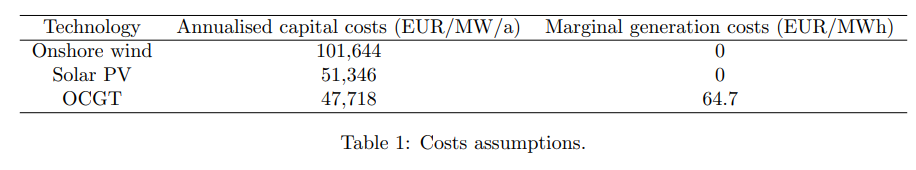

### A.
Calculate the total system cost, the optimal installed capacities, the annual generation per technology,
and plot the hourly generation and demand during January.